In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import infection_model as model

DAYS = 60
N_AGENTS = 5000
# --- Define Parameters ---
params = model.Params(
    T=DAYS * 24, # 10 days
    N=N_AGENTS,
    alpha=3,
    initial_infected_normal=5,        # 5 normal people start infected (I0)
    initial_infected_multispreader=2, # 2 super-spreaders start infected (I0)
    exposed=0,                        # 0 people start exposed (E)
    ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1,
    primary_care=5,
    hospitals=1,
    other_working_places=2,
    public_places=6,
)

# --- Plot ---
def plot_results(df, N):
    colors = {
        "S": "tab:blue", "E": "gold", "I_total": "orange",
        "H": "tab:red", "R": "tab:green", "D": "black"
    }
    plt.figure(figsize=(8, 4))
    
    if "I_total" not in df.columns:
        df["I_total"] = df["I0"] + df["I1"] + df["I2"]

    plt.plot(df["days"], df["S"], label="Susceptible", color=colors["S"], linestyle="--")
    plt.plot(df["days"], df["E"], label="Exposed", color=colors["E"])
    plt.plot(df["days"], df["I_total"], label="Infectious (Total)", color=colors["I_total"], linewidth=2.5)
    plt.plot(df["days"], df["H"], label="Hospitalized", color=colors["H"])
    plt.plot(df["days"], df["R"], label="Recovered", color=colors["R"])
    plt.plot(df["days"], df["D"], label="Dead", color=colors["D"])

    plt.xlabel("Days")
    plt.ylabel("Population Count")
    plt.title(f"SEIRHD Model (Init I0_N={params.initial_infected_normal} I0_M={params.initial_infected_multispreader})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

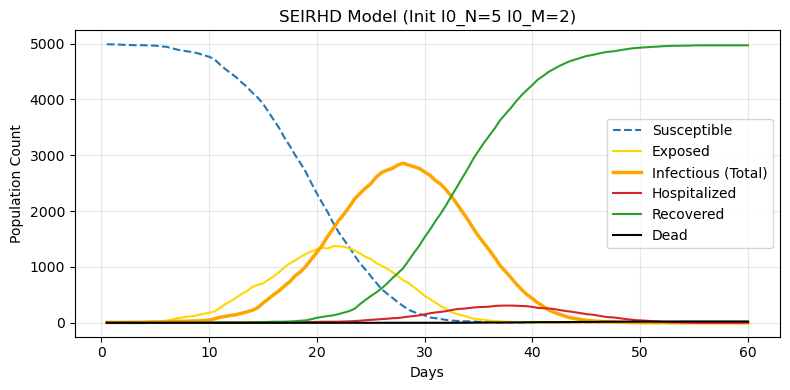

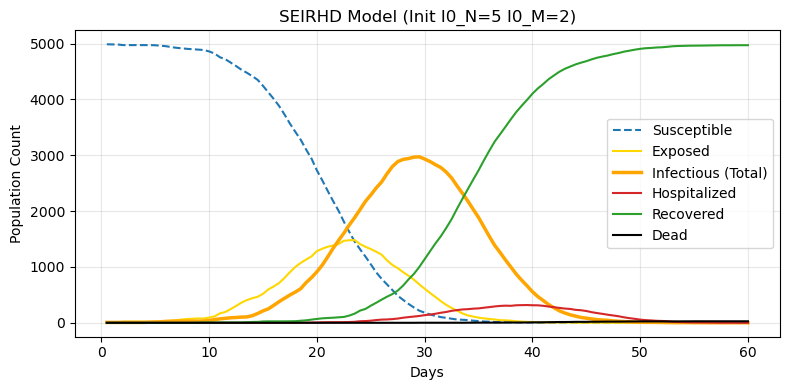

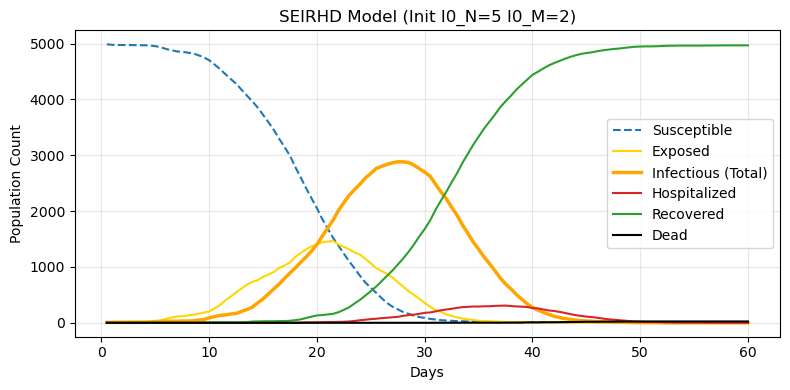

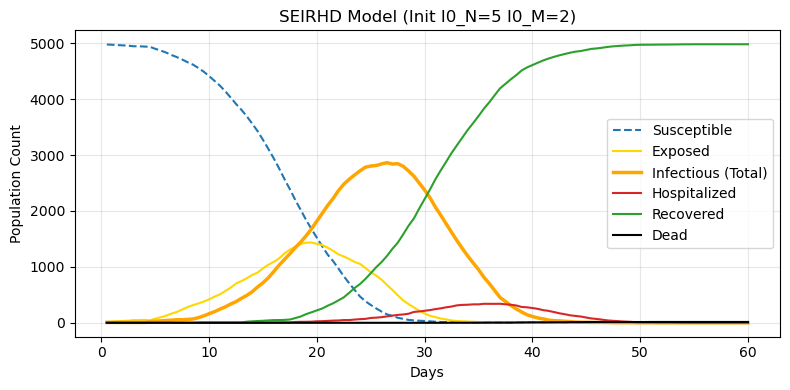

In [12]:
for i in range(4):
    sim = model.Simulation(params=params, seed=i)
    sim.init()
    sim.run(dt=12.0) 
    df = pd.DataFrame(sim.get_stats_df())
    df["days"] = df["time"] / 24
    plot_results(df, params.N)

For different seeds the results are VERY similar.

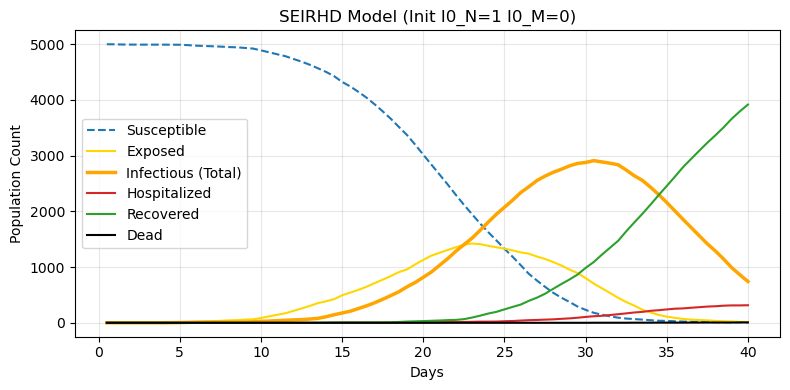

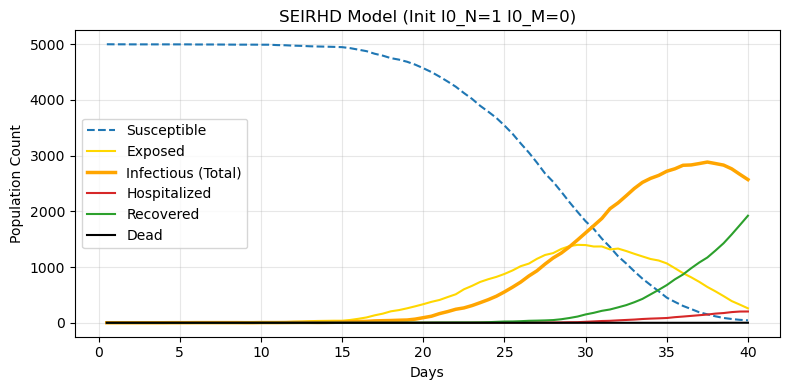

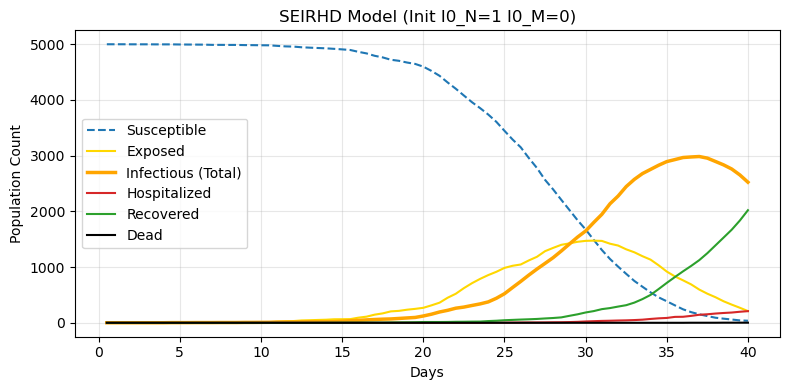

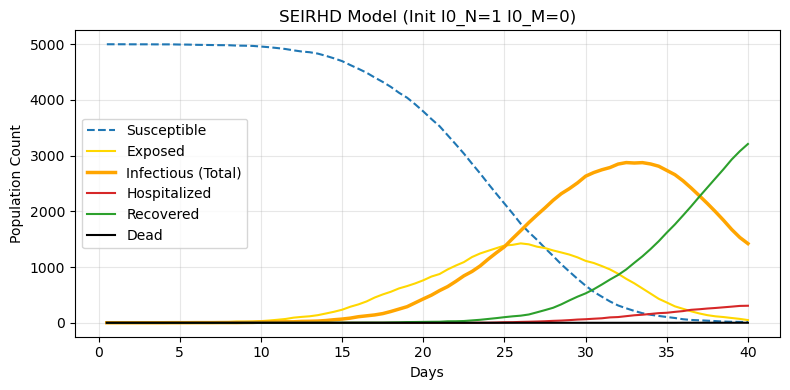

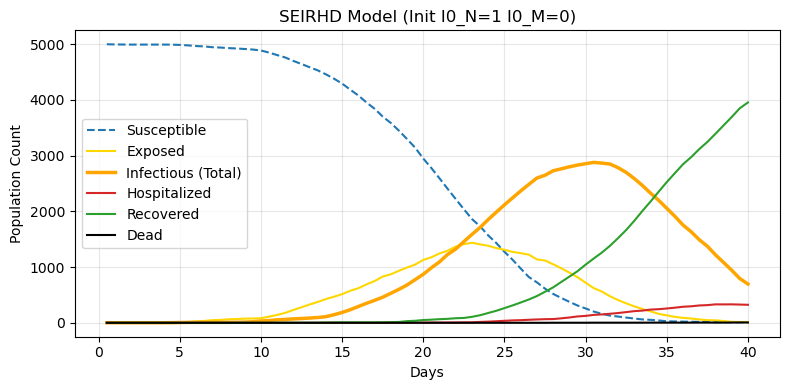

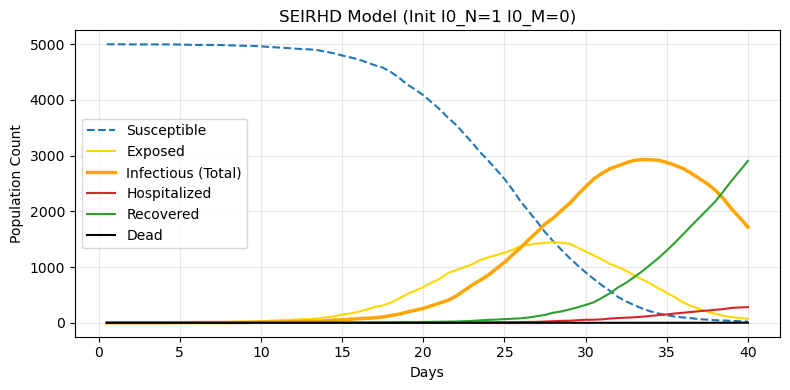

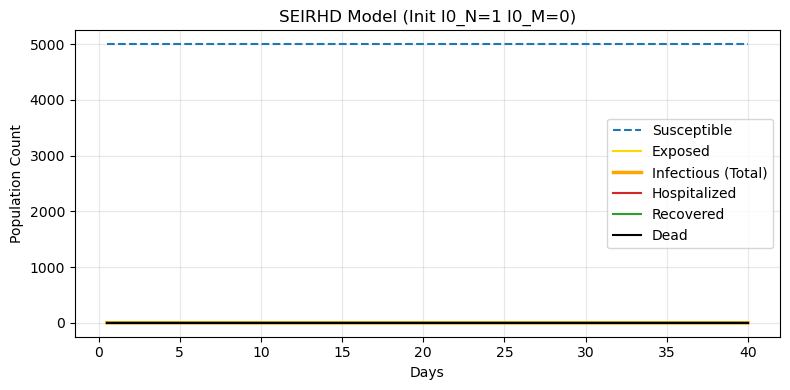

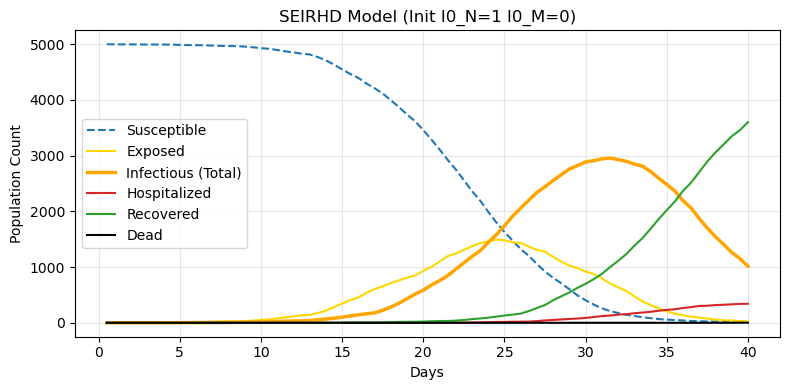

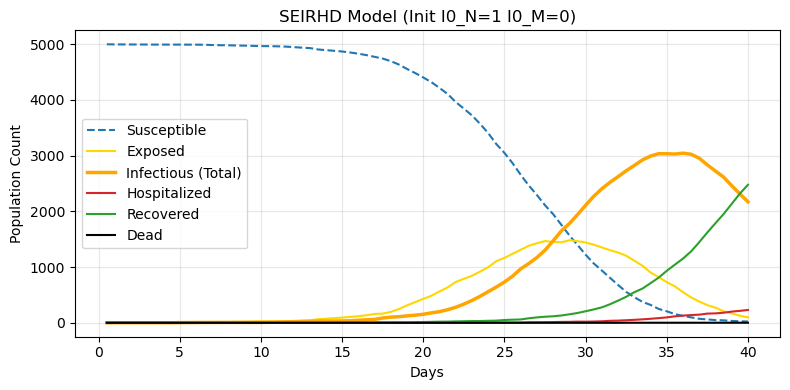

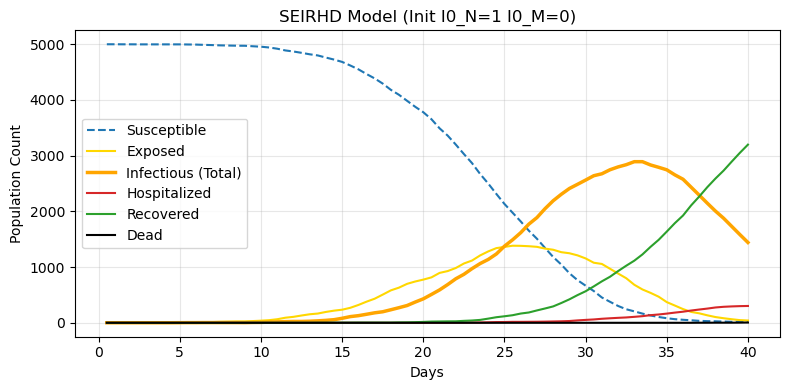

In [ ]:
for i in range(4):
    sim = model.Simulation(params=params, seed=i)
    sim.init()
    sim.run(dt=12.0) 
    df = pd.DataFrame(sim.get_stats_df())
    df["days"] = df["time"] / 24
    plot_results(df, params.N)

For very small number of initially infected the model has more variance, but the virus also doesn't seem to extinct. in the paper they decided on 10 infecrted initial (out of 100k) 8 normal, 2 multi. We have 5k now, so the model seems to scale reasonably (we need 0.5: 0.4N and 0.1M to have corresponding initial conditions).

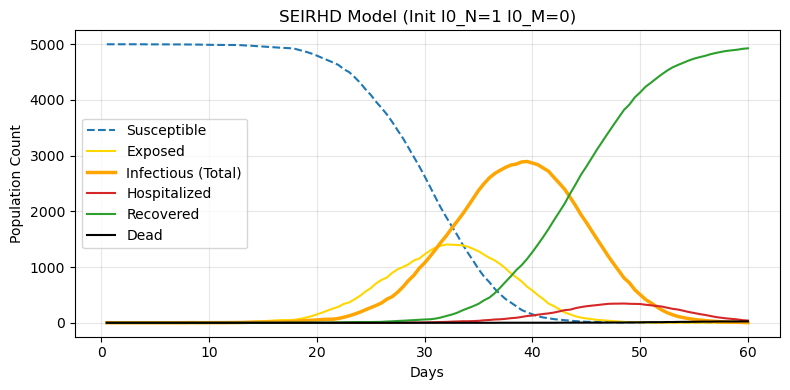

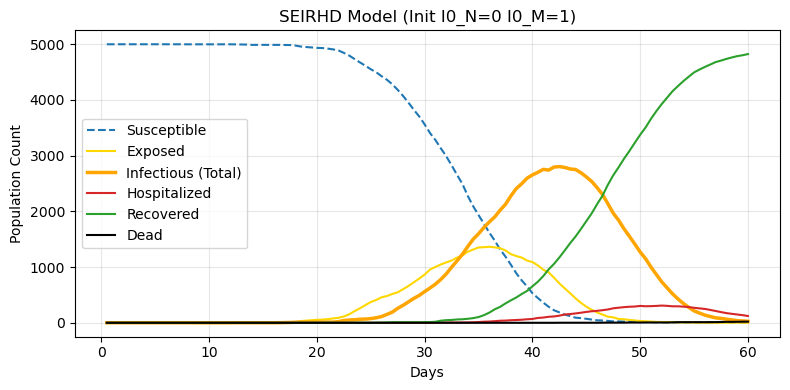

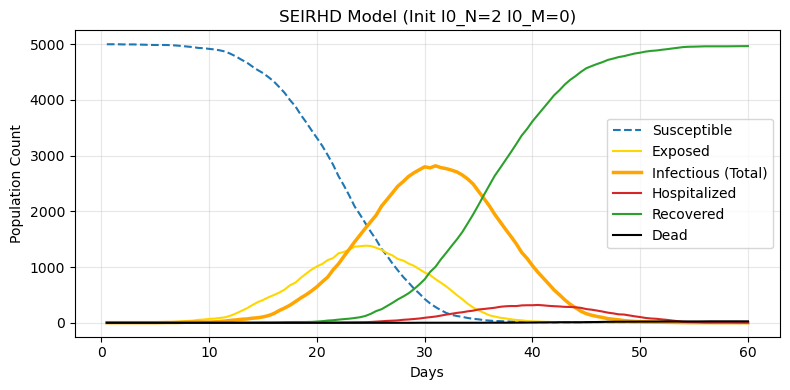

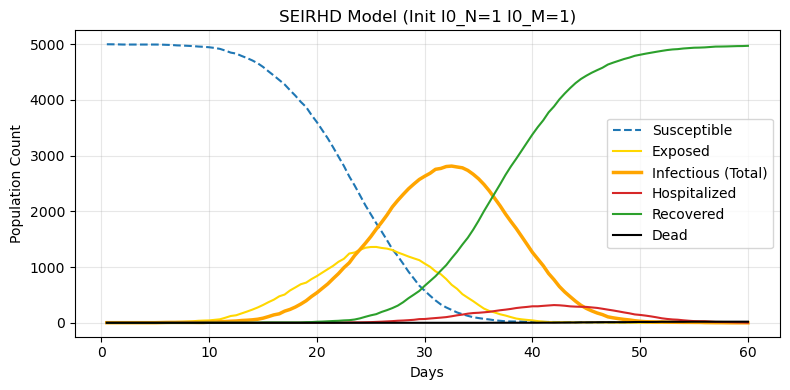

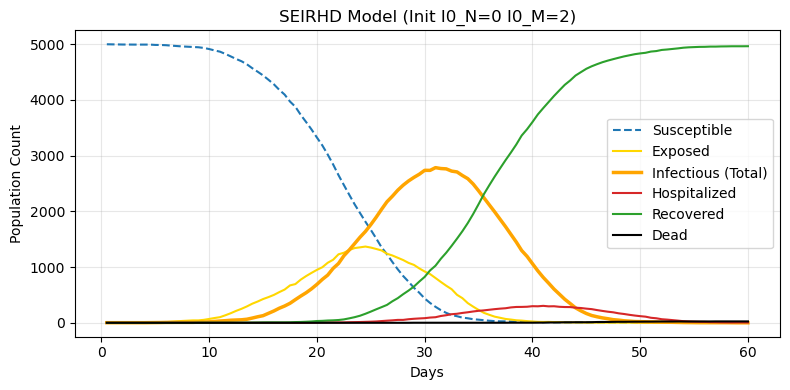

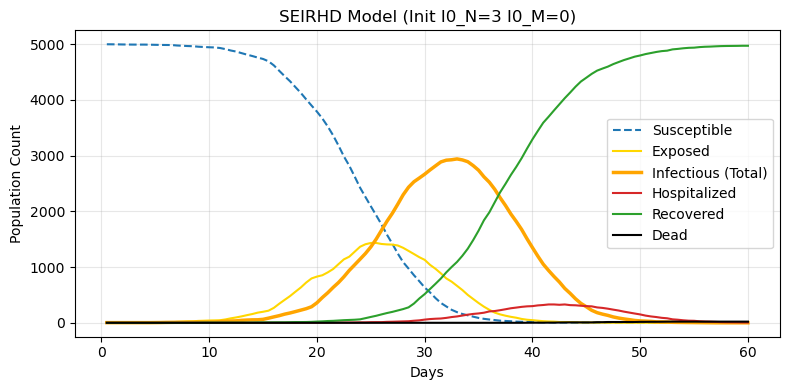

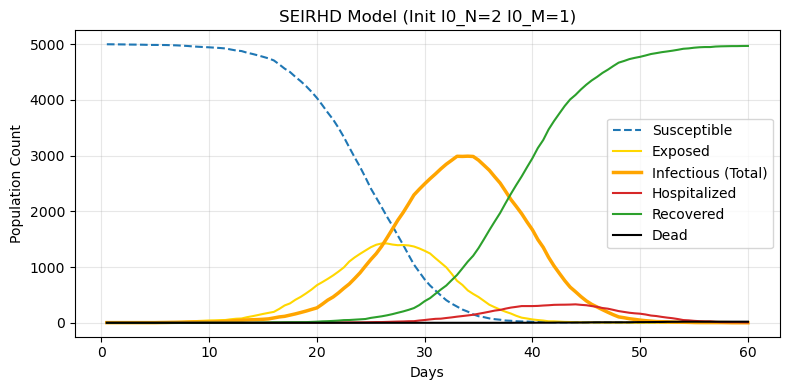

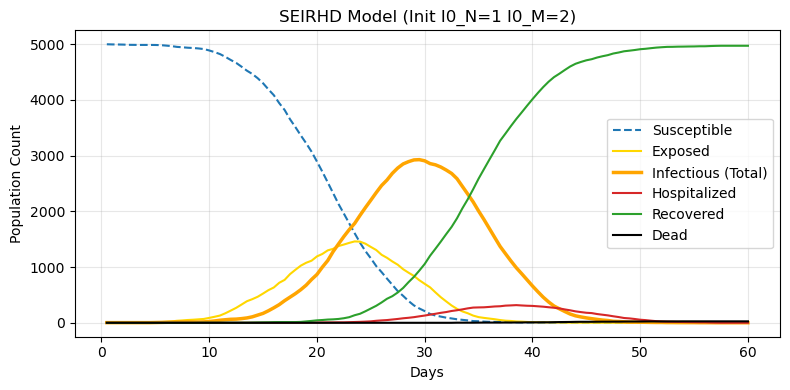

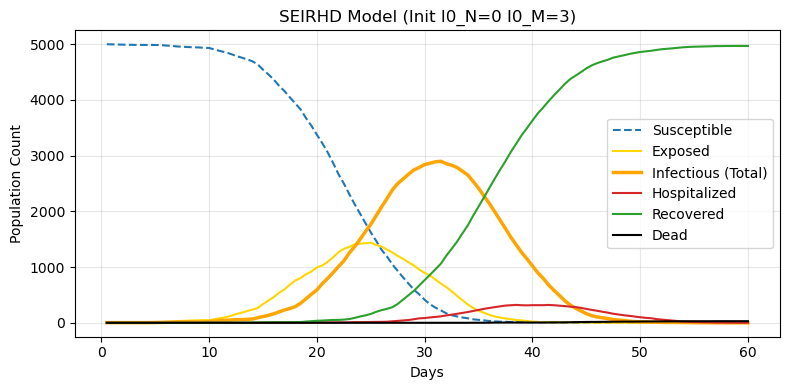

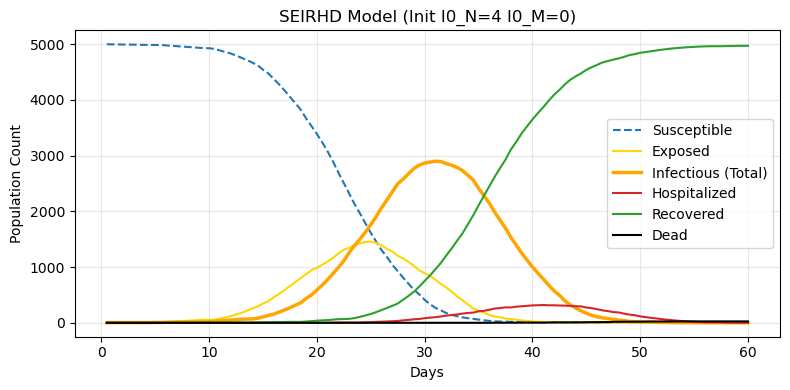

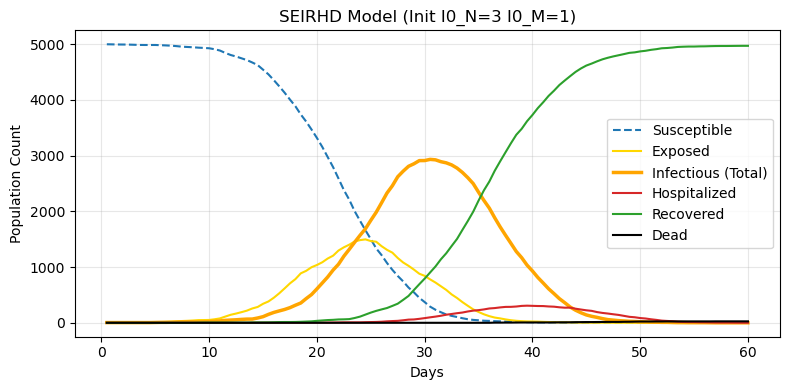

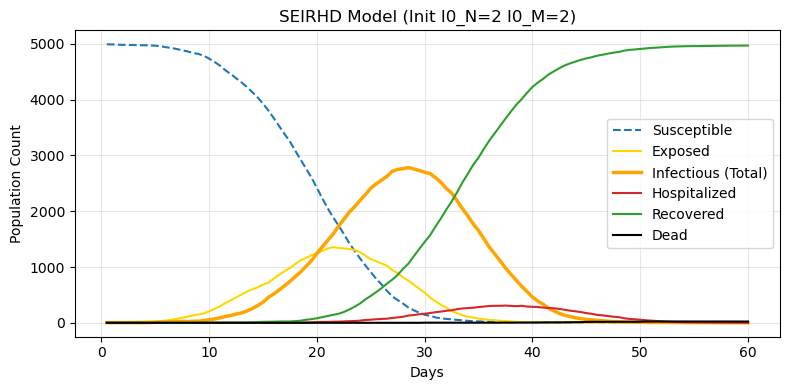

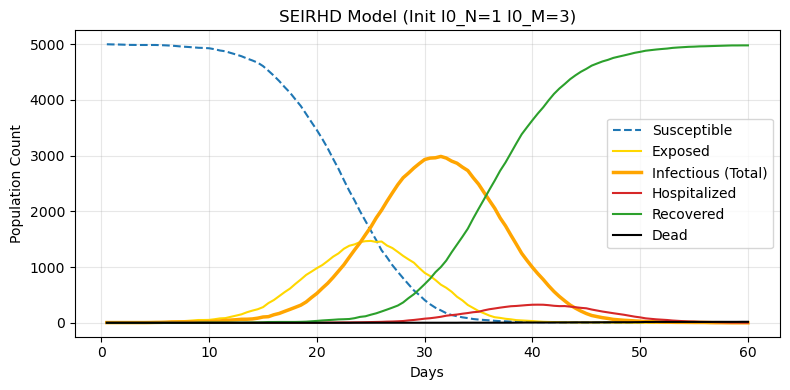

In [14]:
DAYS=60
for i in range(1,5):
    for j in range(min(i,3)+1):
        params = model.Params(
            T=DAYS * 24, # 10 days
            N=N_AGENTS,
            alpha=3,
            
            # NEW PARAMETERS:
            initial_infected_normal=i-j,        # 5 normal people start infected (I0)
            initial_infected_multispreader=j, # 2 super-spreaders start infected (I0)
            exposed=0,                        # 0 people start exposed (E)
            
            ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
            schools=1,
            primary_care=5,
            hospitals=1,
            other_working_places=2,
            public_places=6,
        )
        sim = model.Simulation(params=params, seed=22)
        sim.init()
        sim.run(dt=12.0) 
        df = pd.DataFrame(sim.get_stats_df())
        df["days"] = df["time"] / 24
        plot_results(df, params.N)

Although the number of initially infected seems to influence time of peak, it seems that the height is quite stable.